# Phase 2 

 ### Block 1: Imports and Setup

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import EuroSAT
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split

# Reproducibility — critical for research
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")


PyTorch version: 2.12.0+cu130
Device: CUDA


### Block 2: Download EuroSAT

In [2]:
# Minimal transform for EDA - we want to see raw data
eda_transform = transforms.Compose([
    transforms.ToTensor()   # Only convert to tensor, no normalization
])

# This downloads EuroSAT to ./data/ directory (~90MB)
full_dataset = EuroSAT(
    root='./data',
    transform=eda_transform,
    download=True
)

class_names = full_dataset.classes
print(f"Total images: {len(full_dataset)}")
print(f"Classes ({len(class_names)}): {class_names}")


Total images: 27000
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### Block 3: Class Distribution Analysis


📊 Class Distribution:
Class                             Count   Percentage
----------------------------------------------------
AnnualCrop                         3000        11.1%
Forest                             3000        11.1%
HerbaceousVegetation               3000        11.1%
Highway                            2500         9.3%
Industrial                         2500         9.3%
Pasture                            2000         7.4%
PermanentCrop                      2500         9.3%
Residential                        3000        11.1%
River                              2500         9.3%
SeaLake                            3000        11.1%


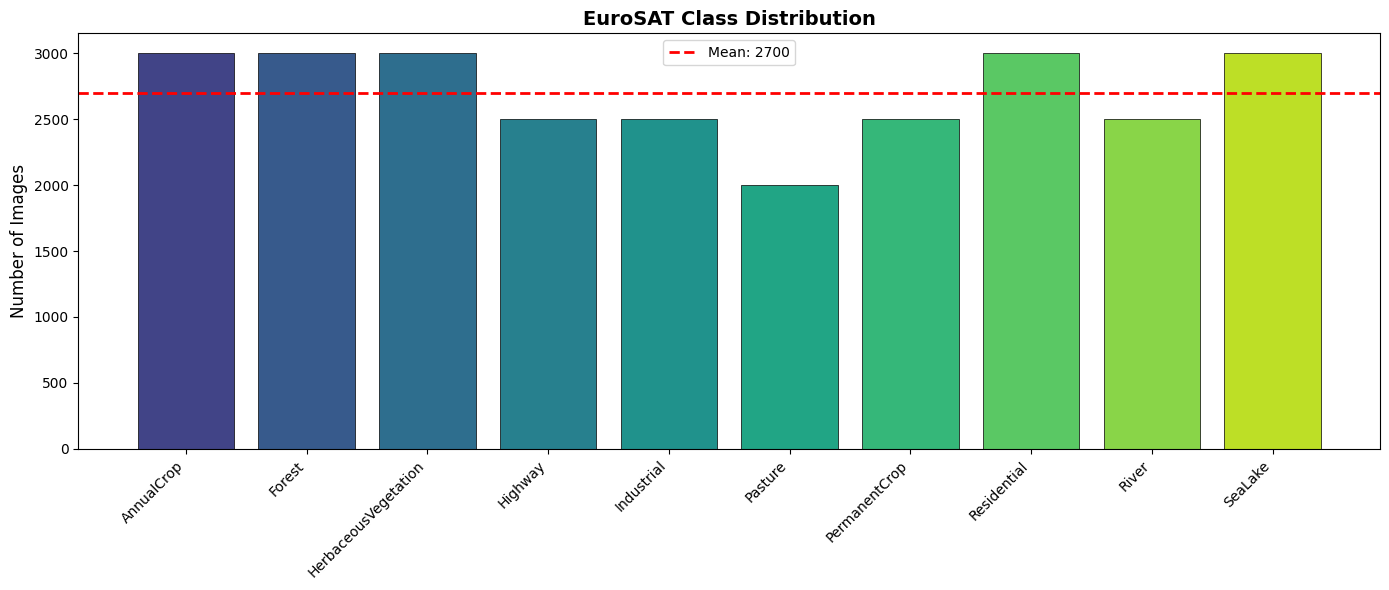


Most common class: AnnualCrop (3000 images)
Least common class: Pasture (2000 images)
Imbalance ratio: 1.50x


In [3]:
# Count images per class
all_labels = [full_dataset[i][1] for i in range(len(full_dataset))]
class_counts = Counter(all_labels)

# Print distribution
print("\n📊 Class Distribution:")
print(f"{'Class':<30} {'Count':>8} {'Percentage':>12}")
print("-" * 52)
for idx, name in enumerate(class_names):
    count = class_counts[idx]
    pct = (count / len(full_dataset)) * 100
    print(f"{name:<30} {count:>8} {pct:>11.1f}%")

# Visualize as bar chart
plt.figure(figsize=(14, 6))
counts = [class_counts[i] for i in range(len(class_names))]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(class_names)))

bars = plt.bar(class_names, counts, color=colors, edgecolor='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylabel('Number of Images', fontsize=12)
plt.title('EuroSAT Class Distribution', fontsize=14, fontweight='bold')
plt.axhline(y=np.mean(counts), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {np.mean(counts):.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print(f"\nMost common class: {class_names[np.argmax(counts)]} ({max(counts)} images)")
print(f"Least common class: {class_names[np.argmin(counts)]} ({min(counts)} images)")
print(f"Imbalance ratio: {max(counts)/min(counts):.2f}x")


### Block 4: Visual Sample Inspection

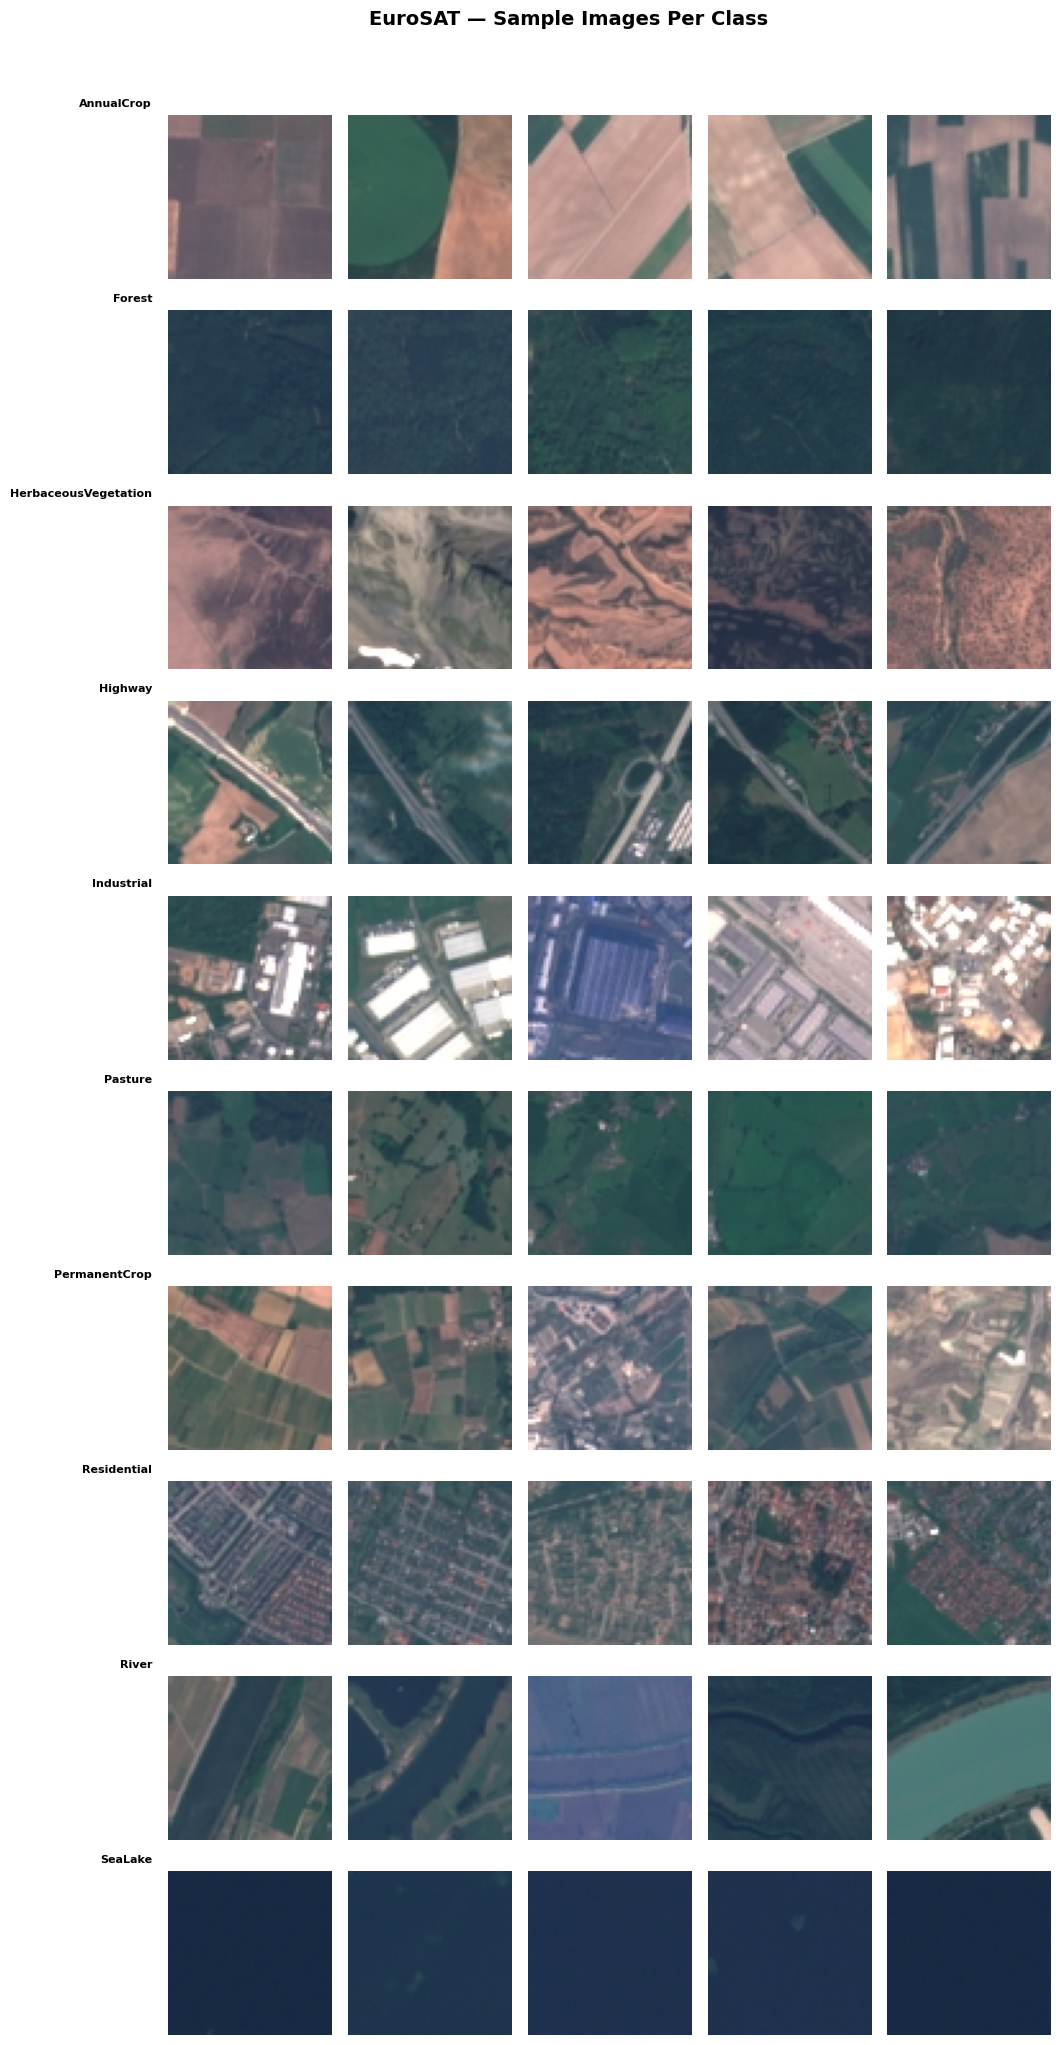

In [4]:
def show_class_samples(dataset, class_names, n_samples=5):
    """Show n_samples images for each class in a grid."""
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, n_samples, 
                              figsize=(n_samples * 2, n_classes * 2))
    fig.suptitle('EuroSAT — Sample Images Per Class', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # Collect samples per class
    class_images = {i: [] for i in range(n_classes)}
    for img, label in dataset:
        if len(class_images[label]) < n_samples:
            class_images[label].append(img)
        if all(len(v) == n_samples for v in class_images.values()):
            break
    
    for class_idx in range(n_classes):
        for sample_idx in range(n_samples):
            ax = axes[class_idx][sample_idx]
            img = class_images[class_idx][sample_idx]
            
            # Convert tensor [C,H,W] → numpy [H,W,C] for display
            img_np = img.permute(1, 2, 0).numpy()
            img_np = np.clip(img_np, 0, 1)  # Ensure valid range
            
            ax.imshow(img_np)
            ax.axis('off')
            if sample_idx == 0:
                ax.set_title(class_names[class_idx], 
                           fontsize=8, fontweight='bold', 
                           rotation=0, ha='right', x=-0.1)
    
    plt.tight_layout()
    plt.savefig('class_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

show_class_samples(full_dataset, class_names)


### Block 5: Pixel Statistics (Mean & Std per channel)

In [3]:
# Compute mean and std across entire dataset
# Note: This takes a few minutes for 27,000 images
print("Computing pixel statistics (this may take 2-3 minutes)...")

# Stack all images into one large tensor
# In practice, we do this in batches to avoid memory overflow
loader = torch.utils.data.DataLoader(full_dataset, batch_size=512, 
                                      shuffle=False, num_workers=0)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
total_pixels = 0

for images, _ in loader:
    # images shape: [batch, 3, 64, 64]
    channel_sum += images.sum(dim=[0, 2, 3])      # Sum over batch, H, W
    channel_sq_sum += (images**2).sum(dim=[0, 2, 3])
    total_pixels += images.shape[0] * images.shape[2] * images.shape[3]

mean = channel_sum / total_pixels
std = torch.sqrt(channel_sq_sum / total_pixels - mean**2)

print(f"\n📊 EuroSAT Pixel Statistics:")
print(f"Mean (R, G, B): {mean.tolist()}")
print(f"Std  (R, G, B): {std.tolist()}")

print(f"\n📊 ImageNet Pixel Statistics (for comparison):")
print(f"Mean (R, G, B): [0.485, 0.456, 0.406]")
print(f"Std  (R, G, B): [0.229, 0.224, 0.225]")

print(f"\nMean difference from ImageNet: {(mean - torch.tensor([0.485, 0.456, 0.406])).abs().mean():.4f}")


Computing pixel statistics (this may take 2-3 minutes)...

📊 EuroSAT Pixel Statistics:
Mean (R, G, B): [0.3443760275840759, 0.3802909553050995, 0.4077703654766083]
Std  (R, G, B): [0.20266073942184448, 0.13689634203910828, 0.11554991453886032]

📊 ImageNet Pixel Statistics (for comparison):
Mean (R, G, B): [0.485, 0.456, 0.406]
Std  (R, G, B): [0.229, 0.224, 0.225]

Mean difference from ImageNet: 0.0727


### Block 6: Stratified Split

In [4]:
# Get all labels for stratification
all_labels = np.array([full_dataset[i][1] for i in range(len(full_dataset))])
all_indices = np.arange(len(full_dataset))

# First split: separate test set (15%)
train_val_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.15,
    stratify=all_labels,   # ← Ensures proportional class representation
    random_state=42
)

# Second split: separate validation from train (15% of total = ~17.6% of train_val)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.176,        # 0.176 × 0.85 ≈ 0.15 of total
    stratify=all_labels[train_val_idx],
    random_state=42
)

print(f"✅ Dataset Split Summary:")
print(f"  Training:   {len(train_idx):,} images ({len(train_idx)/len(full_dataset)*100:.1f}%)")
print(f"  Validation: {len(val_idx):,} images  ({len(val_idx)/len(full_dataset)*100:.1f}%)")
print(f"  Test:       {len(test_idx):,} images  ({len(test_idx)/len(full_dataset)*100:.1f}%)")


✅ Dataset Split Summary:
  Training:   18,910 images (70.0%)
  Validation: 4,040 images  (15.0%)
  Test:       4,050 images  (15.0%)


# Phase 3 — Baseline CNN Code

### Block 1 — Model Definition

In [5]:
import torch
import torch.nn as nn

class BaselineCNN(nn.Module):
    """
    Simple 3-block CNN trained from scratch.
    Purpose: Scientific baseline to measure Transfer Learning impact.
    No pretrained weights. No residual connections. Pure vanilla CNN.
    """
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()

        # ── CONVOLUTIONAL BACKBONE ──────────────────────
        # Block 1: Large receptive field to capture broad spatial patterns
        # 7×7 kernel with stride=2 aggressively downsamples early (like ResNet)
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32,
                      kernel_size=7, stride=2, padding=3, bias=False),
            # bias=False because BatchNorm has its own bias term (beta)
            # Adding both is redundant and wastes parameters
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )  # Output: 56 × 56 × 32

        # Block 2: 3×3 for efficient fine-grained texture learning
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )  # Output: 28 × 28 × 64

        # Block 3: Deeper semantic feature extraction
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )  # Output: 14 × 14 × 128

        # ── CLASSIFICATION HEAD ──────────────────────────
        # Flatten: 14 × 14 × 128 = 25,088
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(25088, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),   # Kill 50% of neurons randomly during training
            nn.Linear(512, num_classes)
            # No Softmax here — CrossEntropyLoss includes it internally
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


# ── SANITY CHECK ─────────────────────────────────────────
# Always verify your architecture with a dummy forward pass
model = BaselineCNN(num_classes=10)
dummy_input = torch.randn(1, 3, 224, 224)   # Batch=1, C=3, H=224, W=224
output = model(dummy_input)
print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {output.shape}")        # Should be [1, 10]
print(f"Output (logits): {output}")           # Raw values, not probabilities

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Input shape:  torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 10])
Output (logits): tensor([[-0.5366,  0.4573, -0.2108, -0.4490,  0.1652,  0.1378,  0.1471,  0.8881,
         -0.0520,  0.2551]], grad_fn=<AddmmBackward0>)

Total parameters:     12,948,010
Trainable parameters: 12,948,010


### Block 2 — Dataset and DataLoaders

In [6]:
import torchvision.transforms as transforms
from torchvision.datasets import EuroSAT
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np

# ── TRANSFORMS ────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── STRATIFIED SPLIT ──────────────────────────────────────
full_dataset = EuroSAT(root='./data', transform=None, download=False)
all_labels = np.array([full_dataset[i][1] for i in range(len(full_dataset))])
all_indices = np.arange(len(full_dataset))

train_val_idx, test_idx = train_test_split(
    all_indices, test_size=0.15, stratify=all_labels, random_state=42)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.176,
    stratify=all_labels[train_val_idx], random_state=42)

# ── APPLY TRANSFORMS VIA SUBSET WRAPPER ──────────────────
class TransformSubset(torch.utils.data.Dataset):
    """Applies different transforms to a Subset of a dataset."""
    def __init__(self, subset_indices, base_dataset, transform):
        self.indices = subset_indices
        self.base = base_dataset
        self.transform = transform

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.base[self.indices[idx]]
        if self.transform: img = self.transform(img)
        return img, label

base_ds = EuroSAT(root='./data', transform=None, download=False)
train_ds = TransformSubset(train_idx, base_ds, train_transform)
val_ds   = TransformSubset(val_idx,   base_ds, val_test_transform)
test_ds  = TransformSubset(test_idx,  base_ds, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")


Train: 18,910 | Val: 4,040 | Test: 4,050


### Block 3 — Training Setup

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = BaselineCNN(num_classes=10).to(device)

# Loss: CrossEntropyLoss (includes Softmax internally)
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam with weight decay (L2 regularization to prevent overfitting)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# LR Scheduler: Reduce LR by 50% if val_loss plateaus for 3 epochs
# This prevents getting stuck at a learning rate that's too large
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print("Model, optimizer, scheduler ready.")
print(f"Initial LR: {optimizer.param_groups[0]['lr']}")


Training on: cuda
Model, optimizer, scheduler ready.
Initial LR: 0.001


In [8]:
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")

# Check model is on GPU
param = next(model.parameters())
print(f"Model on: {param.device}")


Device: cuda
CUDA available: True
GPU name: NVIDIA GeForce RTX 4050 Laptop GPU
Model on: cuda:0


### Block 4 — Training Loop

In [11]:
from sklearn.metrics import f1_score
import time

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()   # Enables Dropout and BatchNorm in training mode
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()          # Clear gradients from last step
        outputs = model(images)        # Forward pass
        loss = criterion(outputs, labels)
        loss.backward()                # Compute gradients
        optimizer.step()               # Update weights

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100. * correct / total


def evaluate(model, loader, criterion, device, class_names):
    model.eval()   # Disables Dropout, fixes BatchNorm running stats
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():   # No gradient computation during evaluation
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro') * 100
    return total_loss / total, 100. * correct / total, macro_f1


# ── TRAINING LOOP ─────────────────────────────────────────
EPOCHS = 20
class_names = full_dataset.classes
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0

print(f"\n{'Epoch':>5} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>10} {'Macro F1':>10} {'LR':>10}")
print("─" * 65)

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device, class_names)

    scheduler.step(val_loss)   # Adjust LR based on validation loss
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    # Save best model based on Macro-F1 (not accuracy!)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'baseline_cnn_best.pth')
        best_marker = " ← BEST"
    else:
        best_marker = ""

    elapsed = time.time() - start
    print(f"{epoch:>5} {train_loss:>12.4f} {val_loss:>10.4f} {val_acc:>9.2f}% {val_f1:>9.2f}%  {current_lr:.2e}{best_marker}")

print(f"\n✅ Training complete. Best Macro-F1: {best_val_f1:.2f}%")
print(f"   Best model saved to: baseline_cnn_best.pth")



Epoch   Train Loss   Val Loss    Val Acc   Macro F1         LR
─────────────────────────────────────────────────────────────────
    1       2.1031     1.3877     50.94%     43.51%  1.00e-03 ← BEST
    2       1.5637     1.2799     51.98%     48.65%  1.00e-03 ← BEST
    3       1.4756     1.1615     54.58%     49.61%  1.00e-03 ← BEST
    4       1.3764     1.0878     60.32%     56.58%  1.00e-03 ← BEST
    5       1.2931     1.0168     60.74%     54.90%  1.00e-03
    6       1.2128     0.8354     69.68%     64.60%  1.00e-03 ← BEST
    7       1.1572     0.8963     68.76%     64.38%  1.00e-03
    8       1.1012     0.7688     71.73%     67.87%  1.00e-03 ← BEST
    9       1.0526     0.7493     72.95%     69.55%  1.00e-03 ← BEST
   10       1.0245     0.8032     70.74%     67.75%  1.00e-03
   11       1.0010     0.7196     74.33%     71.54%  1.00e-03 ← BEST
   12       0.9616     0.7262     73.00%     69.32%  1.00e-03
   13       0.9428     0.7164     75.30%     73.78%  1.00e-03 ← BEST
 

### Block 5 — Confusion Matrix of Scratch (BaseLine) CNN

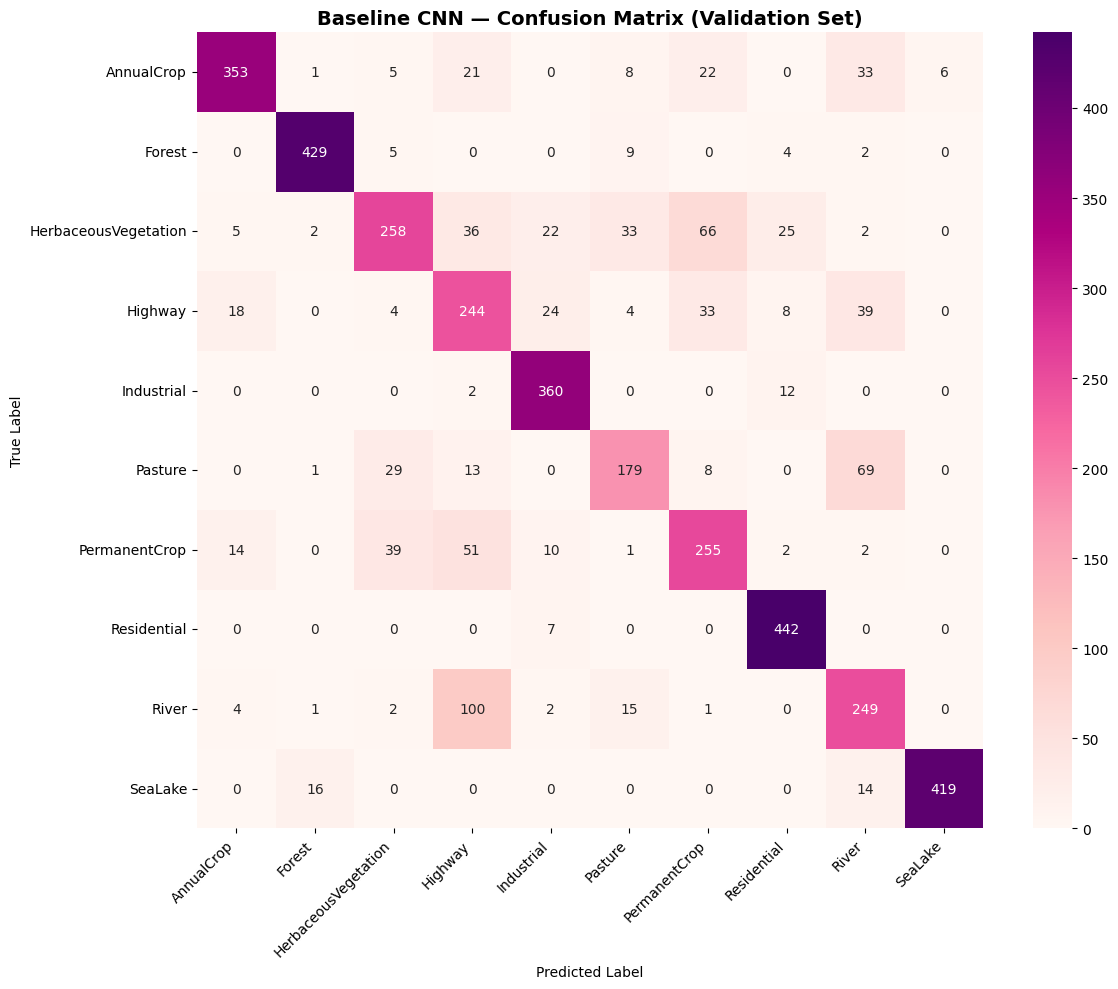

                      precision    recall  f1-score   support

          AnnualCrop       0.90      0.79      0.84       449
              Forest       0.95      0.96      0.95       449
HerbaceousVegetation       0.75      0.57      0.65       449
             Highway       0.52      0.65      0.58       374
          Industrial       0.85      0.96      0.90       374
             Pasture       0.72      0.60      0.65       299
       PermanentCrop       0.66      0.68      0.67       374
         Residential       0.90      0.98      0.94       449
               River       0.61      0.67      0.64       374
             SeaLake       0.99      0.93      0.96       449

            accuracy                           0.79      4040
           macro avg       0.78      0.78      0.78      4040
        weighted avg       0.80      0.79      0.79      4040



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load('baseline_cnn_best.pth'))
model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels.numpy())

class_names = full_dataset.classes
cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline CNN — Confusion Matrix (Validation Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(all_labels_list, all_preds, target_names=class_names))


# Phase 4 — ResNet18 Transfer Learning

### Block 1: Model Definition & Freezing

In [9]:
import torchvision.models as models
import torch.nn as nn

# ── LOAD PRETRAINED ResNet18 ──────────────────────────────────
# weights='IMAGENET1K_V1' = trained on 1.2M natural images, 1000 classes
resnet18 = models.resnet18(weights='IMAGENET1K_V1')

# ── FREEZE CONV1-2 EQUIVALENT ────────────────────────────────
# conv1 + bn1 = very first layer (edge detectors, universal)
# layer1 + layer2 = ResNet blocks 1 & 2 (textures, patterns, universal)
# These are kept frozen — we TRUST ImageNet's training here
for param in resnet18.conv1.parameters():
    param.requires_grad = False
for param in resnet18.bn1.parameters():
    param.requires_grad = False
for param in resnet18.layer1.parameters():
    param.requires_grad = False
for param in resnet18.layer2.parameters():
    param.requires_grad = False

# ── REPLACE FC HEAD FOR EUROSAT ──────────────────────────────
# Original ResNet18: 512 → 1000 (ImageNet classes)
# EuroSAT task:      512 → 10  (our 10 land-use classes)
resnet18.fc = nn.Linear(512, 10)

# Move to GPU
resnet18 = resnet18.to(device)

# ── PARAMETER AUDIT ──────────────────────────────────────────
total_params     = sum(p.numel() for p in resnet18.parameters())
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  ← only these update")
print(f"Frozen parameters:    {frozen_params:,}   ← locked ImageNet weights")
print(f"Frozen ratio:         {frozen_params/total_params*100:.1f}%")

# ── SANITY CHECK: verify frozen layers ───────────────────────
print("\nLayer freeze status:")
for name, param in resnet18.named_parameters():
    if any(x in name for x in ['conv1', 'bn1', 'layer1', 'layer2']):
        status = "        🔒 FROZEN" if not param.requires_grad else "✅ TRAINABLE"
        print(f"  {name:<30} {status}")


Total parameters:     11,181,642
Trainable parameters: 10,498,570  ← only these update
Frozen parameters:    683,072   ← locked ImageNet weights
Frozen ratio:         6.1%

Layer freeze status:
  conv1.weight                           🔒 FROZEN
  bn1.weight                             🔒 FROZEN
  bn1.bias                               🔒 FROZEN
  layer1.0.conv1.weight                  🔒 FROZEN
  layer1.0.bn1.weight                    🔒 FROZEN
  layer1.0.bn1.bias                      🔒 FROZEN
  layer1.0.conv2.weight                  🔒 FROZEN
  layer1.0.bn2.weight                    🔒 FROZEN
  layer1.0.bn2.bias                      🔒 FROZEN
  layer1.1.conv1.weight                  🔒 FROZEN
  layer1.1.bn1.weight                    🔒 FROZEN
  layer1.1.bn1.bias                      🔒 FROZEN
  layer1.1.conv2.weight                  🔒 FROZEN
  layer1.1.bn2.weight                    🔒 FROZEN
  layer1.1.bn2.bias                      🔒 FROZEN
  layer2.0.conv1.weight                  🔒 FROZEN
  laye

### Block 2: Discriminative Learning Rate Setup

In [10]:
# ── DISCRIMINATIVE LEARNING RATES ────────────────────────────
# The BIG idea: different parts of the network need different LRs
#
#  layer3/layer4: Already have GOOD features from ImageNet.
#                 Use SMALL LR (1e-4) to nudge gently towards satellite imagery.
#                 Too large → destroy what ImageNet taught us (Catastrophic Forgetting)
#
#  fc (new head): Brand new layer, randomly initialized.
#                 Use LARGER LR (1e-3) to learn quickly from scratch.
#
# Frozen layers (conv1, bn1, layer1, layer2): NOT in optimizer at all.

optimizer_resnet = torch.optim.Adam([
    {'params': resnet18.layer3.parameters(), 'lr': 1e-4},
    {'params': resnet18.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet18.fc.parameters(),     'lr': 1e-3},
], weight_decay=1e-4)

scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet, mode='min', patience=3, factor=0.5
)

print("✅ Discriminative LR Setup:")
for i, group in enumerate(optimizer_resnet.param_groups):
    layer_name = ['layer3', 'layer4', 'fc'][i]
    print(f"  {layer_name:<8}: LR = {group['lr']:.0e}")

print(f"\nBaseline CNN used:  uniform LR = 1e-3 across ALL layers")
print(f"ResNet18 uses:      1e-4 for fine-tuned layers, 1e-3 for new fc head")
print(f"→ This prevents Catastrophic Forgetting of ImageNet features")


✅ Discriminative LR Setup:
  layer3  : LR = 1e-04
  layer4  : LR = 1e-04
  fc      : LR = 1e-03

Baseline CNN used:  uniform LR = 1e-3 across ALL layers
ResNet18 uses:      1e-4 for fine-tuned layers, 1e-3 for new fc head
→ This prevents Catastrophic Forgetting of ImageNet features


### Block 3: Training Loop (15 epochs)

In [15]:
from sklearn.metrics import f1_score
import time

# Re-define helpers (needed if you skipped Phase 3 training cell)
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion, device, class_names):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro') * 100
    return total_loss / total, 100. * correct / total, macro_f1

# ── TRAINING LOOP ─────────────────────────────────────────────
EPOCHS = 15
best_val_f1_resnet = 0.0
history_resnet = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

print(f"\n{'Epoch':>5} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>10} {'Macro F1':>10} {'LR(fc)':>10}")
print("─" * 65)

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        resnet18, train_loader, criterion, optimizer_resnet, device)
    val_loss, val_acc, val_f1 = evaluate(
        resnet18, val_loader, criterion, device, class_names)

    scheduler_resnet.step(val_loss)
    current_lr = optimizer_resnet.param_groups[2]['lr']  # fc layer LR

    history_resnet['train_loss'].append(train_loss)
    history_resnet['val_loss'].append(val_loss)
    history_resnet['val_acc'].append(val_acc)
    history_resnet['val_f1'].append(val_f1)

    if val_f1 > best_val_f1_resnet:
        best_val_f1_resnet = val_f1
        torch.save(resnet18.state_dict(), 'resnet18_eurosat_best.pth')
        best_marker = " ← BEST"
    else:
        best_marker = ""

    elapsed = time.time() - start
    print(f"{epoch:>5} {train_loss:>12.4f} {val_loss:>10.4f} "
          f"{val_acc:>9.2f}% {val_f1:>9.2f}%  {current_lr:.2e}{best_marker}")

print(f"\n✅ Training complete!")
print(f"   ResNet18 Best Macro-F1:  {best_val_f1_resnet:.2f}%")
print(f"   Baseline CNN:            77.83%")
print(f"   Improvement:             +{best_val_f1_resnet - 77.83:.2f}%")
print(f"   Model saved to:          resnet18_eurosat_best.pth")



Epoch   Train Loss   Val Loss    Val Acc   Macro F1     LR(fc)
─────────────────────────────────────────────────────────────────
    1       0.3423     0.1483     94.83%     94.69%  1.00e-03 ← BEST
    2       0.1995     0.1104     95.97%     95.86%  1.00e-03 ← BEST
    3       0.1676     0.1042     96.39%     96.18%  1.00e-03 ← BEST
    4       0.1424     0.0992     96.34%     96.25%  1.00e-03 ← BEST
    5       0.1330     0.1234     96.14%     96.02%  1.00e-03
    6       0.1233     0.0884     97.10%     97.02%  1.00e-03 ← BEST
    7       0.1184     0.0845     97.15%     97.10%  1.00e-03 ← BEST
    8       0.1126     0.0816     97.30%     97.21%  1.00e-03 ← BEST
    9       0.1069     0.0931     96.98%     96.88%  1.00e-03
   10       0.1090     0.0825     97.43%     97.31%  1.00e-03 ← BEST
   11       0.0955     0.0818     97.43%     97.40%  1.00e-03 ← BEST
   12       0.1007     0.0672     97.80%     97.70%  1.00e-03 ← BEST
   13       0.0899     0.0888     96.98%     96.88%  1.0

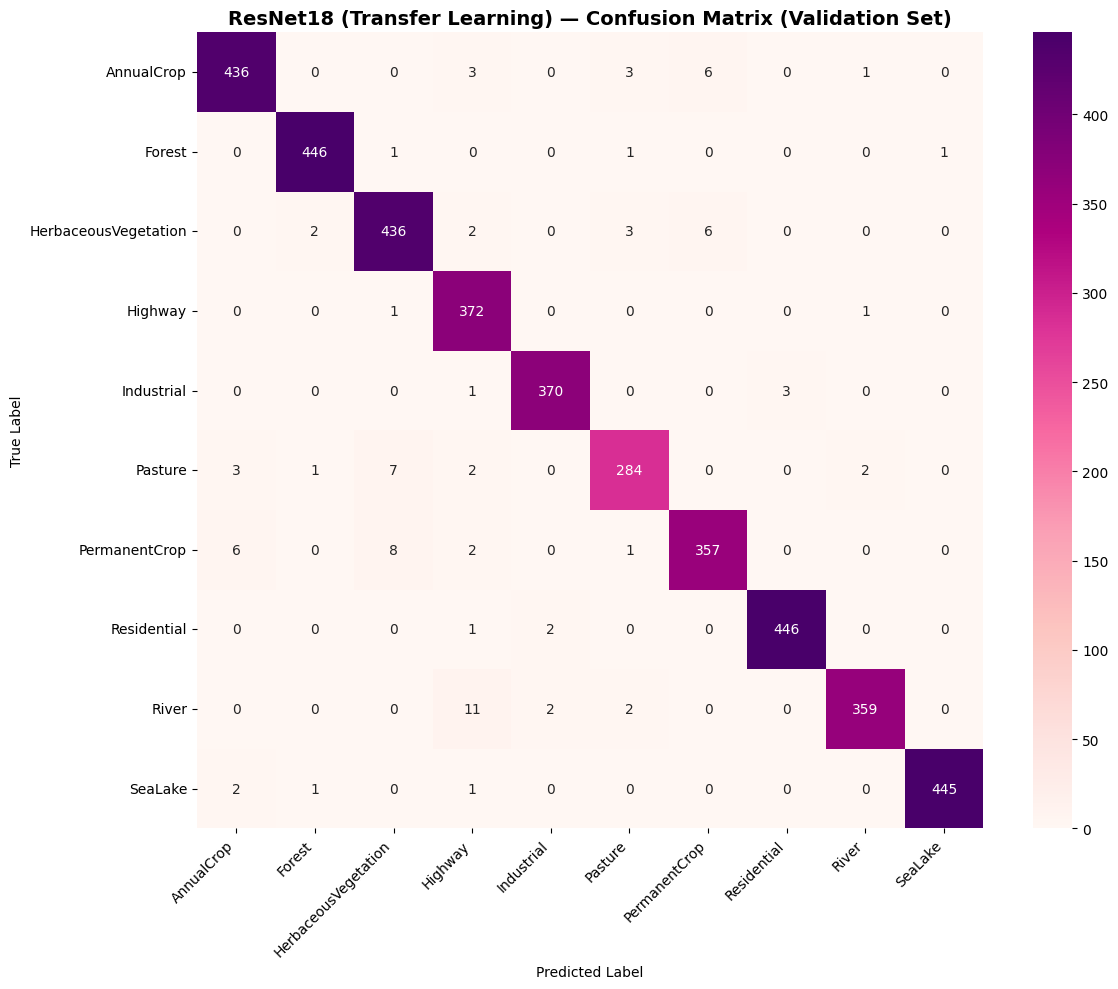

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.97      0.97       449
              Forest       0.99      0.99      0.99       449
HerbaceousVegetation       0.96      0.97      0.97       449
             Highway       0.94      0.99      0.97       374
          Industrial       0.99      0.99      0.99       374
             Pasture       0.97      0.95      0.96       299
       PermanentCrop       0.97      0.95      0.96       374
         Residential       0.99      0.99      0.99       449
               River       0.99      0.96      0.97       374
             SeaLake       1.00      0.99      0.99       449

            accuracy                           0.98      4040
           macro avg       0.98      0.98      0.98      4040
        weighted avg       0.98      0.98      0.98      4040



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load best ResNet18 model
resnet18.load_state_dict(torch.load('resnet18_eurosat_best.pth'))
resnet18.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = resnet18(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels.numpy())

class_names = full_dataset.classes
cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=class_names, yticklabels=class_names)
plt.title('ResNet18 (Transfer Learning) — Confusion Matrix (Validation Set)',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('resnet18_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(all_labels_list, all_preds, target_names=class_names))


# Phase 5: Grad-CAM Implementation

### Block 1: Grad-CAM Engine & Hooks

In [11]:
import torch, cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

gradients, activations = [], []

def save_gradient(module, grad_input, grad_output):
    gradients.append(grad_output[0])

def save_activation(module, input, output):
    activations.append(output)

# Register hooks on layer4
hook_forward  = resnet18.layer4.register_forward_hook(save_activation)
hook_backward = resnet18.layer4.register_full_backward_hook(save_gradient)


### Block 2: Heatmap Computation

In [14]:
def compute_grad_cam(model, image_tensor, class_idx=None):
    gradients.clear(); activations.clear()
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    output = model(image_tensor)
    if class_idx is None: class_idx = output.argmax().item()
    
    model.zero_grad()
    output[0, class_idx].backward()
    
    grad = gradients[0].squeeze()
    act = activations[0].squeeze()
    weights = grad.mean(dim=(1, 2))
    
    cam = (weights[:, None, None] * act).sum(dim=0)
    cam = torch.relu(cam).cpu().detach().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, class_idx

def show_grad_cam(dataset, sample_idx, true_class_name):
    img_tensor, label = dataset[sample_idx]
    cam, pred_idx = compute_grad_cam(resnet18, img_tensor)
    pred_name = class_names[pred_idx]
    
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    img_np = np.clip(img_tensor.permute(1, 2, 0).numpy() * std + mean, 0, 1)
    img_np_uint8 = (img_np * 255).astype(np.uint8)
    
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap_rgb = cv2.cvtColor(cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    overlay = (0.5 * img_np_uint8 + 0.5 * heatmap_rgb).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    axes[0].imshow(img_np); axes[0].set_title(f'Original (True: {true_class_name})'); axes[0].axis('off')
    axes[1].imshow(cam_resized, cmap='jet'); axes[1].set_title('Grad-CAM'); axes[1].axis('off')
    axes[2].imshow(overlay); axes[2].set_title(f'Overlay (Pred: {pred_name})'); axes[2].axis('off')
    
    filename = f'gradcam_{true_class_name}_{sample_idx}.png'
    plt.savefig(filename, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


### Block 3: Execution on Key Classes

✅ Trained weights loaded successfully! Model is now at 97.7% accuracy.


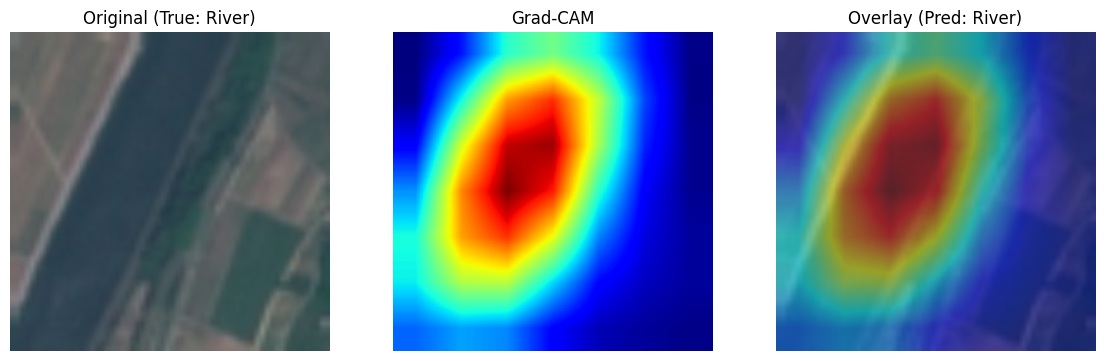

Saved: gradcam_River_21500.png


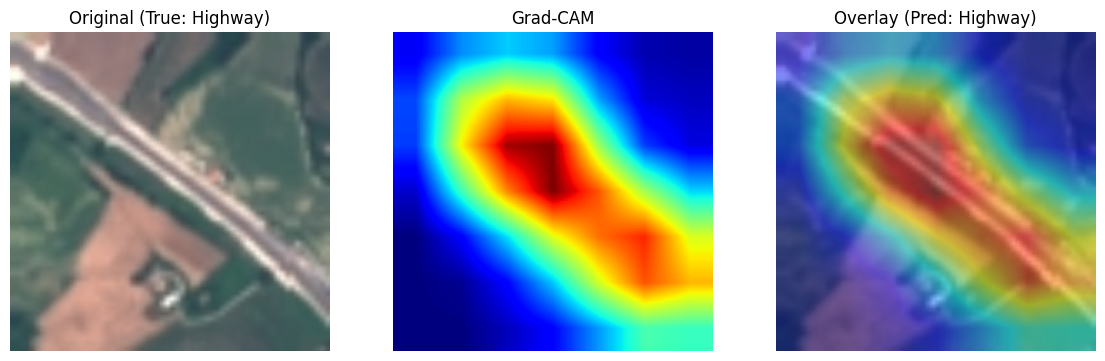

Saved: gradcam_Highway_9000.png


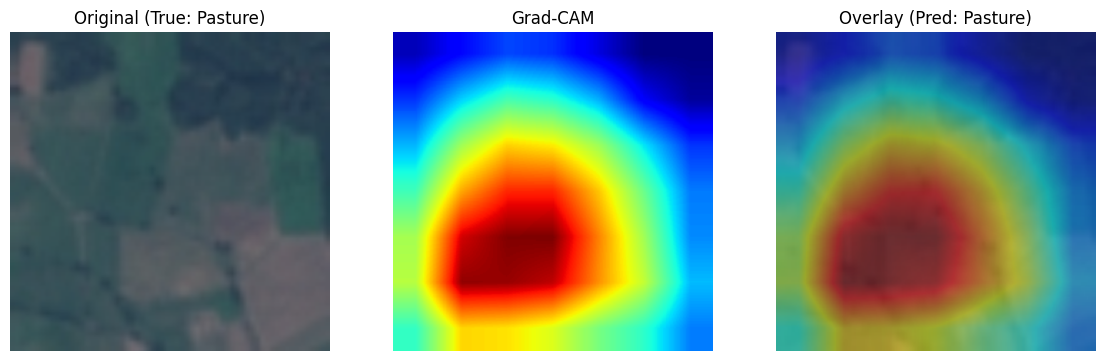

Saved: gradcam_Pasture_14000.png


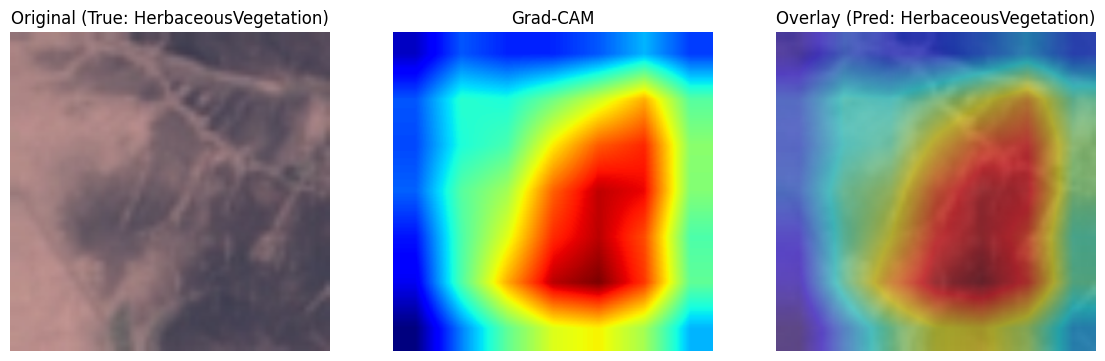

Saved: gradcam_HerbaceousVegetation_6000.png


In [19]:
import torch

# 1. Load your saved Phase 4 weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet18.load_state_dict(torch.load(r'd:\Uttam\Project\Own_Project\Deep Learning\001\experiments\EUROSAT\resnet18_eurosat_best.pth', map_location=device))
resnet18.to(device)
resnet18.eval()

print("✅ Trained weights loaded successfully! Model is now at 97.7% accuracy.")

# 2. Re-run Grad-CAM
for class_name in ['River', 'Highway', 'Pasture', 'HerbaceousVegetation']:
    sample_indices = find_class_samples(gradcam_dataset, class_name, n=1)
    show_grad_cam(gradcam_dataset, sample_indices[0], class_name)


# Phase 6: Error Analysis

🔍 Found 6 examples where True=River, Pred=Highway


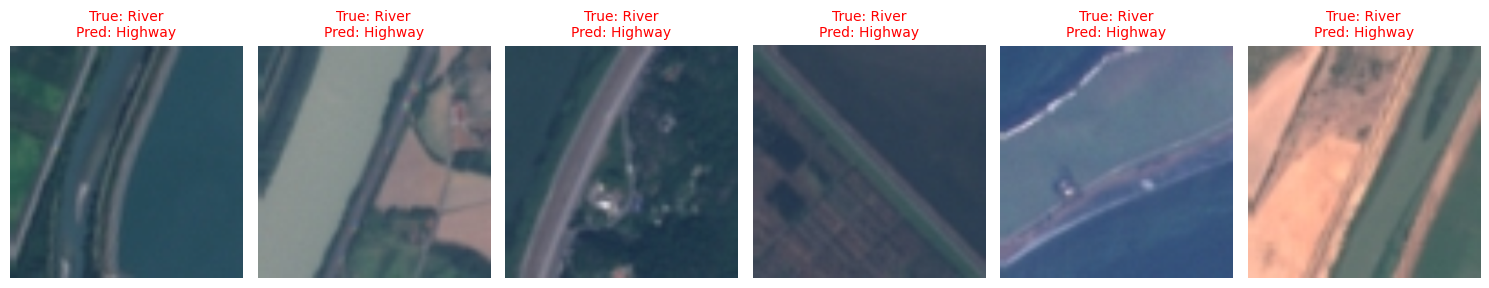

In [20]:
import torch
import matplotlib.pyplot as plt

def visualize_specific_errors(dataset, model, true_class_name, pred_class_name, max_images=6):
    """
    Finds and plots images where the model made a specific confusion mistake.
    """
    model.eval()
    true_idx = class_names.index(true_class_name)
    pred_idx = class_names.index(pred_class_name)
    
    error_images = []
    
    # 1. Sweep through the dataset to find the exact errors
    with torch.no_grad():
        for i in range(len(dataset)):
            img_tensor, label = dataset[i]
            
            # Only look at the true class we care about (River)
            if label == true_idx:
                img_batch = img_tensor.unsqueeze(0).to(device)
                output = model(img_batch)
                prediction = output.argmax().item()
                
                # Did it predict the specific wrong class? (Highway)
                if prediction == pred_idx:
                    error_images.append(img_tensor)
                    if len(error_images) >= max_images:
                        break  # We found enough to look at
                        
    # 2. Plot the errors we found
    if len(error_images) == 0:
        print(f"🎉 No {true_class_name} → {pred_class_name} errors found!")
        return
        
    print(f"🔍 Found {len(error_images)} examples where True={true_class_name}, Pred={pred_class_name}")
    
    # Denormalization for plotting
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    fig, axes = plt.subplots(1, len(error_images), figsize=(15, 4))
    if len(error_images) == 1: axes = [axes]
        
    for ax, img in zip(axes, error_images):
        # Denormalize back to 0-1 range for matplotlib
        img_unnorm = img * std + mean
        img_unnorm = torch.clamp(img_unnorm, 0, 1)
        
        ax.imshow(img_unnorm.permute(1, 2, 0).numpy())
        ax.axis('off')
        ax.set_title(f"True: {true_class_name}\nPred: {pred_class_name}", color='red', fontsize=10)
        
    plt.tight_layout()
    plt.show()

# Let's hunt down those exact River -> Highway errors!
# Note: we use the raw val_dataset to see the clean, un-augmented images
visualize_specific_errors(gradcam_dataset, resnet18, "River", "Highway")
